# Stage 2: Categorical Variable Encoding
**Member:** **M2 — IT25103364**
**Assigned Preprocessing Technique:** Ordinal, one-hot (with grouping) and frequency encoding
**Dataset:** [US Permanent Visa Applications](https://www.kaggle.com/datasets/jboysen/us-perm-visas) (US Department of Labor, via Kaggle)
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Pipeline Position:** Stage 2 of 6 (sequential)
**Input:** `results/outputs/stage1_missing_handled.parquet`
**Output:** `results/outputs/stage2_encoded.parquet`

---
## 1. Explanation of the Technique

Machine-learning models need numeric inputs. The right encoding depends on the variable:
1. **Ordinal encoding** - integer codes that preserve a natural order (e.g. education level). Only valid when the order is real.
2. **One-hot encoding** - one 0/1 column per category, no false order. Becomes impractical for high-cardinality columns.
3. **Grouping / top-k** - collapse rare categories (or long codes) into meaningful groups before one-hot encoding.
4. **Frequency (count) encoding** - replace a category by how often it occurs; one numeric column regardless of cardinality.
5. **Target encoding** - replace a category by its mean target; powerful but leaks the label unless done out-of-fold, so it is **not used** here.

All category lists and counts are learned from the **train rows only**; categories never seen in training fall into `Other` / `Unknown`.

---
## 2. Justification for THIS Dataset Specifically

| Column | Cardinality | Encoding | Why |
|---|---|---|---|
| `pw_level_9089` | 4 | ordinal I-IV -> 1-4 (Unknown 0) | Wage levels are ordered by skill / pay |
| worker / required education | 6 | ordinal High School -> Doctorate = 1-5 (Other/Unknown 0) | Ordered; Stage 4 compares them |
| `job_info_experience` | Y/N | binary | Two values |
| `pw_soc_code` | 1,381 | 2-digit SOC major group (~23) -> one-hot | Occupation family carries the signal; 1,381 dummies would be sparse noise |
| NAICS industry code | ~1,800 | 2-digit sector (20) -> one-hot | Same reasoning; uses `data/external/naics_sectors.csv` |
| employer state | 59 | census region (5) -> one-hot | Regional effect with few columns |
| `pw_source_name_9089` | 6 | one-hot | Low cardinality |
| citizenship | 202 | top 20 + Other -> one-hot | Top 20 cover 89% of applicants |
| `class_of_admission` | 57 | top 10 + Other -> one-hot | H-1B alone is 76% |
| `employer_name` | 71,709 | frequency: other train filings by the same employer | One informative column instead of 71k dummies |

The raw `employer_state`, `job_info_work_state` and `agent_firm_name` are passed through untouched because Stage 4 needs them, and are dropped there.

### Why this must be Stage 2
- It needs Stage 1's cleaned values (validated SOC/NAICS codes, normalised states, `"Unknown"` instead of NaN).
- Outlier treatment (Stage 3) then only touches genuinely continuous columns, and Stage 4 can build features from the ordinal education codes.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

# --- Project paths: search upward for the folder that contains data/raw ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

RAW_CSV = os.path.join(ROOT, 'data', 'raw', 'us_perm_visas.csv')
EXT_DIR = os.path.join(ROOT, 'data', 'external')
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
PLOT_DIR = os.path.join(ROOT, 'results', 'eda_visualizations')
LOG_DIR = os.path.join(ROOT, 'results', 'logs')
for _d in (OUT_DIR, PLOT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
TEST_SIZE = 0.20             # stratified 80/20 split; teammates use 5-fold CV on the train rows
DEV_SAMPLE = None            # e.g. 0.10 for a fast ~35k-row run; None = full dataset
EDA_ONLY_COLS = ['case_status', 'decision_date']                          # kept for EDA, dropped in S6
LEAKAGE_COLS = ['case_id', 'case_received_date', 'application_type', 'processing_days']  # must never reach a model
NON_FEATURE_COLS = EDA_ONLY_COLS + [TARGET, 'split']

REFERENCE_YEAR = 2016                                                     # last year in the dataset
S4_PASSTHROUGH = ['employer_state', 'job_info_work_state', 'agent_firm_name']  # raw columns kept by S2 for S4
SCALE_COLS = ['wage_offer_annual', 'pw_annual', 'wage_gap_annual', 'wage_to_pw_ratio',  # continuous / ordinal
              'employer_num_employees_log', 'employer_filing_count_log', 'employer_yr_estab', 'employer_age',
              'pw_level', 'edu_worker', 'edu_required', 'edu_gap']

# --- Reference tables (data/external) ---
_states = pd.read_csv(os.path.join(EXT_DIR, 'us_states.csv'))
STATE_LOOKUP = {**dict(zip(_states['state_name'], _states['state_code'])),
                **dict(zip(_states['state_code'], _states['state_code']))}
STATE_REGION = dict(zip(_states['state_code'], _states['census_region']))
VALID_SOC = set(pd.read_csv(os.path.join(EXT_DIR, 'soc_major_groups.csv'), dtype=str)['soc_major_group'])
_naics = pd.read_csv(os.path.join(EXT_DIR, 'naics_sectors.csv'), dtype=str)
VALID_NAICS = set(_naics['naics_2digit'])
NAICS_SECTOR_KEY = dict(zip(_naics['naics_2digit'], _naics['sector_key']))

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')

Project root: /Users/jathushansundararasu/Desktop/us_prem_visa


In [2]:
# ==============================================================================
# STAGE 2: Categorical Encoding (M2)
# ==============================================================================
EDU_ORDER = {'High School': 1, "Associate's": 2, "Bachelor's": 3, "Master's": 4, 'Doctorate': 5}  # Other/Unknown -> 0
PW_LEVEL_ORDER = {'Level I': 1, 'Level II': 2, 'Level III': 3, 'Level IV': 4}                     # Unknown -> 0
TOP_K = {'country_of_citizenship': 20, 'class_of_admission': 10}


def _clean_name(value):
    return ''.join(ch if ch.isalnum() else '_' for ch in str(value)).strip('_')


def one_hot(series, categories, prefix, fallback='Other'):
    """One-hot with a FIXED category list (fit on train). Values outside the list go to `fallback`."""
    cats = list(categories) + ([fallback] if fallback not in categories else [])
    values = pd.Categorical(series.where(series.isin(cats), fallback), categories=cats)
    dummies = pd.get_dummies(values, dtype='int8')
    dummies.columns = [f'{prefix}_{_clean_name(c)}' for c in cats]
    dummies.index = series.index
    return dummies


def stage2_categorical_encoding(df, plot_dir=PLOT_DIR, out_dir=OUT_DIR, show_plot=False):
    """
    - Ordinal: pw_level (I-IV -> 1-4), worker / required education (High School -> Doctorate = 1-5); Unknown/Other -> 0.
    - Binary: experience_required (Y -> 1).
    - Grouped one-hot (category lists fit on train): SOC major group, NAICS sector, employer census region,
      prevailing-wage source, citizenship (top 20 + Other), class of admission (top 10 + Other).
    - Frequency: employer_filing_count = number of OTHER train filings by the same employer (71k employers).
    """
    d = df.copy()
    train = d['split'].eq('train')

    d['pw_level'] = d['pw_level_9089'].map(PW_LEVEL_ORDER).fillna(0).astype('int8')
    d['edu_worker'] = d['foreign_worker_info_education'].map(EDU_ORDER).fillna(0).astype('int8')
    d['edu_required'] = d['job_info_education'].map(EDU_ORDER).fillna(0).astype('int8')
    d['experience_required'] = d['job_info_experience'].eq('Y').astype('int8')

    d['employer_region'] = d['employer_state'].map(STATE_REGION).fillna('Unknown')
    d['naics_sector'] = d['naics_2digit'].map(NAICS_SECTOR_KEY).fillna('Unknown')
    specs = {
        'soc_major_group': 'soc', 'naics_sector': 'naics', 'employer_region': 'region',
        'pw_source_name_9089': 'pwsrc', 'country_of_citizenship': 'country', 'class_of_admission': 'coa',
    }
    fitted = {}
    for col, prefix in specs.items():
        counts = d.loc[train, col].value_counts()
        fitted[col] = sorted(counts.head(TOP_K[col]).index) if col in TOP_K else sorted(counts.index)
    # Top-k columns put rare / unseen values in 'Other'; full-list columns send unseen test values to 'Unknown'
    encoded = [one_hot(d[col], fitted[col], prefix, fallback='Other' if col in TOP_K else 'Unknown')
               for col, prefix in specs.items()]

    counts = d.loc[train, 'employer_name'].value_counts()
    filing = d['employer_name'].map(counts).fillna(0)
    d['employer_filing_count'] = (filing - train.astype(int)).astype('int32')   # exclude the row itself on train

    if plot_dir:
        t = d[train]
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        plt.subplots_adjust(wspace=0.3)
        panels = [
            ('pw_level', {0: 'Unknown', 1: 'I', 2: 'II', 3: 'III', 4: 'IV'}, 'Prevailing-wage level (ordinal)'),
            ('edu_worker', {0: 'Other/\nUnknown', 1: 'High\nSchool', 2: 'Assoc.', 3: 'Bach.', 4: 'Master', 5: 'PhD'},
             'Worker education (ordinal)'),
        ]
        for ax, (col, labels, title) in zip(axes[:2], panels):
            rate = t.groupby(col)[TARGET].mean() * 100
            bars = ax.bar([labels[i] for i in rate.index], rate.values, color='#2980b9')
            ax.bar_label(bars, fmt='%.1f%%', fontsize=9, padding=2)
            ax.axhline(t[TARGET].mean() * 100, color='#e74c3c', linestyle='--', label='overall denial rate')
            ax.set_title(f'Denial rate by {title}', fontweight='bold')
            ax.set_ylabel('Denied (%)')
            ax.legend(fontsize=8)
            ax.margins(y=0.15)
        top = t['country_of_citizenship'].value_counts().head(10).index
        rate = t[t['country_of_citizenship'].isin(top)].groupby('country_of_citizenship')[TARGET].mean().reindex(top) * 100
        bars = axes[2].barh(rate.index[::-1], rate.values[::-1], color='#8e44ad')
        axes[2].bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
        axes[2].axvline(t[TARGET].mean() * 100, color='#e74c3c', linestyle='--')
        axes[2].set_title('Denial rate - 10 most common citizenships', fontweight='bold')
        axes[2].set_xlabel('Denied (%)')
        plt.suptitle('m2: Denial risk across encoded categorical attributes (train rows)', fontsize=14, fontweight='bold', y=1.03)
        plt.savefig(f'{plot_dir}/m2_denial_rate_by_category.png', dpi=200, bbox_inches='tight')
        plt.show() if show_plot else plt.close()

    if out_dir:
        maps = {'one_hot_categories': fitted, 'pw_level_order': PW_LEVEL_ORDER, 'education_order': EDU_ORDER}
        with open(os.path.join(out_dir, 'encoding_maps.json'), 'w') as f:
            json.dump(maps, f, indent=2)

    drop = list(specs) + ['pw_level_9089', 'foreign_worker_info_education', 'job_info_education',
                          'job_info_experience', 'naics_2digit', 'employer_name']
    d = pd.concat([d.drop(columns=drop)] + encoded, axis=1)
    features = [c for c in d.columns if c not in NON_FEATURE_COLS]
    return d[EDA_ONLY_COLS + features + [TARGET, 'split']]

Loaded Stage 1 data: 354,849 rows x 21 columns


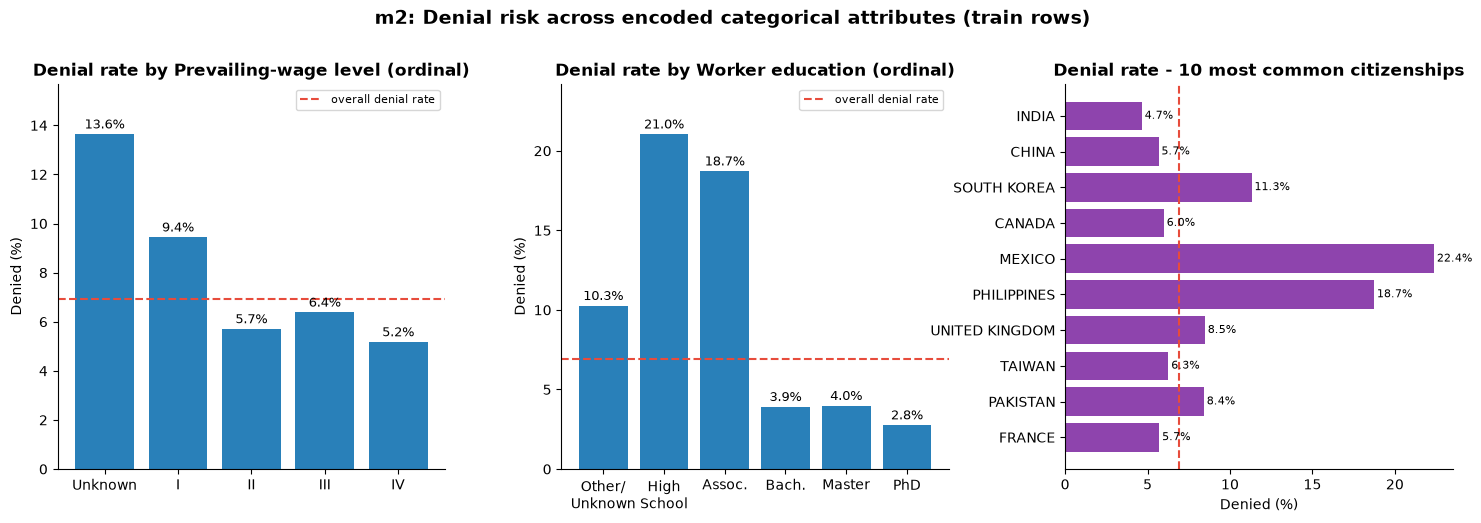

Saved Stage 2 output: 354,849 rows x 106 columns


In [3]:
# 1. Load Stage 1 output and encode (+ EDA plot m2)
df_1 = pd.read_parquet(os.path.join(OUT_DIR, 'stage1_missing_handled.parquet'))
print(f'Loaded Stage 1 data: {df_1.shape[0]:,} rows x {df_1.shape[1]} columns')
df_2 = stage2_categorical_encoding(df_1, show_plot=True)
df_2.to_parquet(os.path.join(OUT_DIR, 'stage2_encoded.parquet'), index=False)
print(f'Saved Stage 2 output: {df_2.shape[0]:,} rows x {df_2.shape[1]} columns')

In [4]:
# 2. Verification ("done when" checks)
non_numeric = [c for c in df_2.columns if c not in NON_FEATURE_COLS + S4_PASSTHROUGH
               and not pd.api.types.is_numeric_dtype(df_2[c])]
assert not non_numeric, f'non-numeric feature columns: {non_numeric}'
with open(os.path.join(OUT_DIR, 'encoding_maps.json')) as f:
    maps = json.load(f)
train_rows = df_1[df_1['split'].eq('train')]
for col, cats in maps['one_hot_categories'].items():
    if col in train_rows:   # naics_sector / employer_region are derived inside Stage 2
        assert set(cats) <= set(train_rows[col].unique()), f'{col}: categories not learned from train rows'
for prefix in ['soc_', 'naics_', 'region_', 'pwsrc_', 'country_', 'coa_']:
    group = [c for c in df_2.columns if c.startswith(prefix)]
    assert (df_2[group].sum(axis=1) == 1).all(), f'{prefix} one-hot rows must sum to 1'
assert len(df_2) == len(df_1)
print('One-hot groups:', {p: sum(c.startswith(p) for c in df_2.columns) for p in ['soc_', 'naics_', 'region_', 'pwsrc_', 'country_', 'coa_']})
print('All Stage 2 checks passed.')

One-hot groups: {'soc_': 23, 'naics_': 21, 'region_': 7, 'pwsrc_': 7, 'country_': 21, 'coa_': 11}
All Stage 2 checks passed.


## 3. EDA Interpretation & Findings

1. **Prevailing-wage level is ordered in risk:** Level I jobs are denied 9.4% of the time vs 5.2-6.4% for Levels II-IV, and applications with no level recorded are denied 13.6% of the time - supporting an ordinal code.
2. **Education is the clearest gradient:** High School (21.0%) and Associate's (18.7%) applicants are denied ~5x more often than Bachelor's (3.9%), Master's (4.0%) and Doctorate (2.8%) applicants (overall rate 6.9%).
3. **Citizenship matters:** among the 10 most common countries, Mexico (22.4%), the Philippines (18.7%) and South Korea (11.3%) sit well above average, India (4.7%) and China (5.7%) below - which is why the top-20 countries keep their own columns.
4. **Hand-off to Stage 3:** every model feature is now numeric (ordinal, binary, one-hot or count); only the three passthrough columns remain as text for Stage 4.